In [16]:
# ノートブックの環境変数設定
%env DATA_ROOT /home/ryo52/LAIME/atmacup11

env: DATA_ROOT=/home/ryo52/LAIME/atmacup11


In [17]:
import os
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import japanize_matplotlib

import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import warnings
from contextlib import contextmanager
import time
from collections import defaultdict
import math

# PyTorch 関連
import torch
from torch import nn
from torch.utils import data
from torchvision import transforms as T
from torch.optim import Adam
from torch.optim.optimizer import Optimizer

# CV と評価
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error

# モデル (timm) とロギング (wandb)
import timm
import wandb

# 警告を非表示に
warnings.filterwarnings('ignore')

# ノートブックで使われていたvivid.utils.timerの代替
@contextmanager
def timer(prefix=""):
    start = time.time()
    yield
    end = time.time()
    print(f"[{prefix}] {end - start:.2f} sec")

print(f"PyTorch Version: {torch.__version__}")
print(f"timm Version: {timm.__version__}")

PyTorch Version: 2.9.0+cu128
timm Version: 1.0.22


In [18]:
# ---------------------------------
# ディレクトリ設定 (ノートブックの構成を流用)
# ---------------------------------

dataset_root = os.environ.get('DATA_ROOT', './atmacup11') # 環境変数がなければカレント配下を想定

input_dir = os.path.join(dataset_root, "inputs")
photo_dir = os.path.join(input_dir, "photos")

# このベースライン用の出力ディレクトリ
output_dir = os.path.join(dataset_root, "outputs_baseline_resnet18d")
os.makedirs(output_dir, exist_ok=True)

print(f"Input Dir: {input_dir}")
print(f"Output Dir: {output_dir}")

# ---------------------------------
# デバイス設定 (ノートブックの構成を流用)
# ---------------------------------
assert torch.cuda.is_available()
DEVICE = torch.device("cuda")
print(f"DEVICE: {DEVICE}")

Input Dir: /home/ryo52/LAIME/atmacup11/inputs
Output Dir: /home/ryo52/LAIME/atmacup11/outputs_baseline_resnet18d
DEVICE: cuda


In [19]:
train_df = pd.read_csv(os.path.join(input_dir, 'train.csv'))
test_df = pd.read_csv(os.path.join(input_dir, 'test.csv'))
submission_df = pd.read_csv(os.path.join(input_dir, 'atmaCup#11_sample_submission.csv'))

print(f"train_df: {train_df.shape}")
print(f"test_df: {test_df.shape}")
train_df.head()

train_df: (3937, 4)
test_df: (5919, 1)


,object_id,sorting_date,art_series_id,target
0,002bff09b09998d0be65,1631,509357f67692a6a45626,1
1,00309fb1ef05416f9c1f,1900,7987b47bbe5dc3039179,3
2,003a1562e97f79ba96dc,1834,ded7c3c9636708e5b14c,3
3,004890880e8e7431147b,1743,582ac2d7f0cef195b605,2
4,00718c32602425f504c1,1885,64c907f0c08dce4fb8e8,3


In [20]:
# 画像サイズ計測
heights = []
widths = []
ratios = []  # height / width
object_ids = train_df["object_id"].tolist()

from PIL import Image

with timer("read image sizes"):
    for oid in tqdm(object_ids):
        path = os.path.join(photo_dir, f"{oid}.jpg")
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
        ratios.append(h / w)

train_df["width"] = widths
train_df["height"] = heights
train_df["aspect_ratio"] = ratios

train_df[["object_id", "height", "width", "aspect_ratio"]].head()


100%|██████████| 3937/3937 [00:00<00:00, 55157.61it/s]

[read image sizes] 0.07 sec


,object_id,height,width,aspect_ratio
0,002bff09b09998d0be65,109,224,0.486607
1,00309fb1ef05416f9c1f,164,224,0.732143
2,003a1562e97f79ba96dc,224,152,1.473684
3,004890880e8e7431147b,224,174,1.287356
4,00718c32602425f504c1,224,132,1.696970


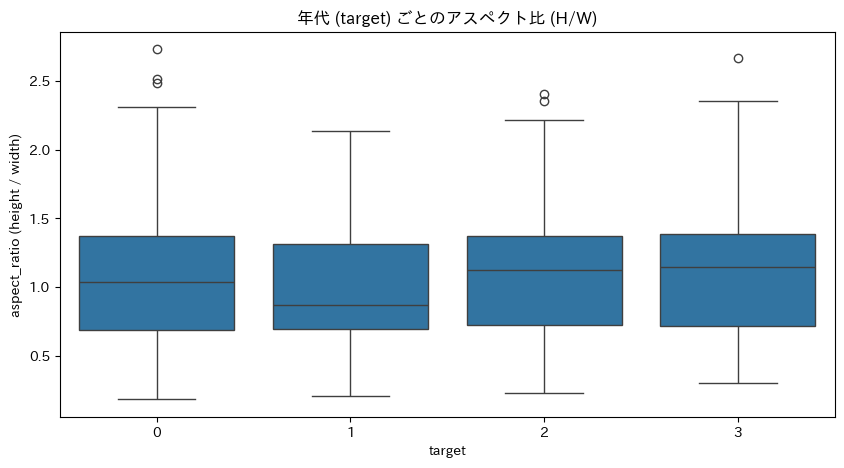

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_df, x="target", y="aspect_ratio")
plt.title("年代 (target) ごとのアスペクト比 (H/W)")
plt.xlabel("target")
plt.ylabel("aspect_ratio (height / width)")
plt.show()


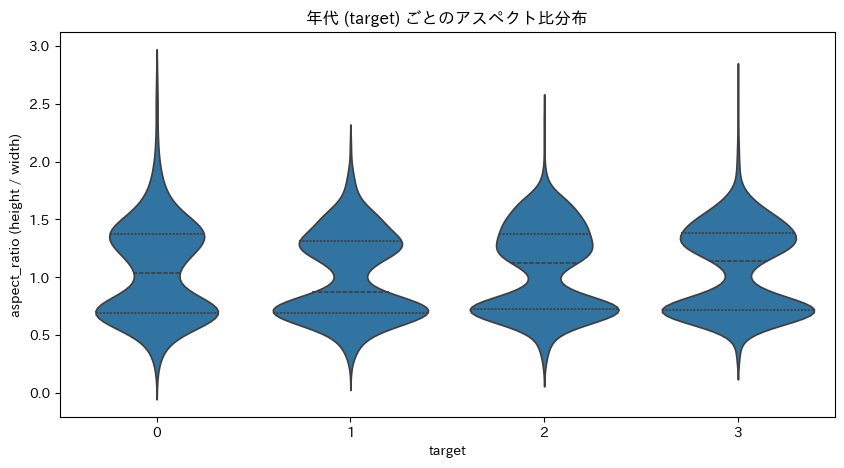

In [22]:
plt.figure(figsize=(10, 5))
sns.violinplot(data=train_df, x="target", y="aspect_ratio", inner="quartile")
plt.title("年代 (target) ごとのアスペクト比分布")
plt.xlabel("target")
plt.ylabel("aspect_ratio (height / width)")
plt.show()


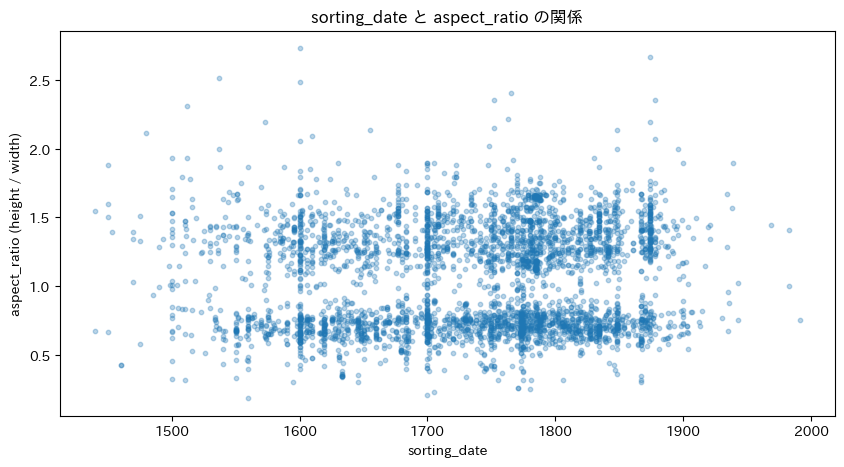

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(train_df["sorting_date"], train_df["aspect_ratio"], s=10, alpha=0.3)
plt.title("sorting_date と aspect_ratio の関係")
plt.xlabel("sorting_date")
plt.ylabel("aspect_ratio (height / width)")
plt.show()


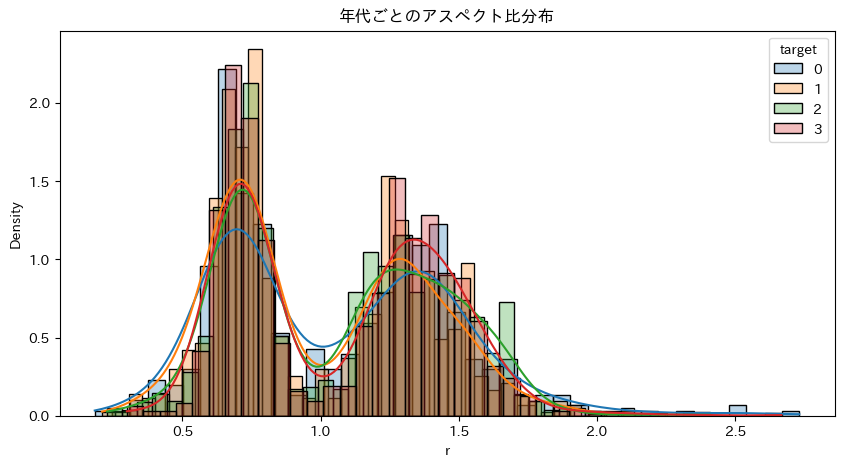

In [24]:
plt.figure(figsize=(10,5))
for t in sorted(train_df["target"].unique()):
    subset = train_df[train_df["target"] == t]
    sns.histplot(subset["aspect_ratio"], kde=True, stat="density", bins=40, label=str(t), alpha=0.3)

plt.legend(title="target")
plt.xlabel("r")
plt.ylabel("Density")
plt.title("年代ごとのアスペクト比分布")
plt.show()
